In [28]:
import cv2

# قراءة الصورة
image = cv2.imread(r"C:\Users\PC-LAB1\Downloads\WhatsApp Image 2026-09-22 at 11.27.28 AM.jpeg")

# تحويل إلى رمادي
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# استخراج الأجسام الداكنة فقط
_, thresh = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY_INV)

# اكتشاف الأجسام
contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

count = 0

for contour in contours:

    # حساب مساحة الجسم
    area = cv2.contourArea(contour)

    # تجاهل النقاط والأجسام الصغيرة
    if area < 10:
        continue

    count += 1

    # رسم حدود الجسم
    cv2.drawContours(image, [contour], -1, (0, 0, 255), 2)

# كتابة عدد الأجسام على الصورة
cv2.putText(
    image,
    f"Dark Objects: {count}",
    (20, 40),
    cv2.FONT_HERSHEY_SIMPLEX,
    1,
    (0, 0, 255),
    2
)

print("Number of dark objects:", count)

# عرض الصورة
cv2.imshow("Dark Objects", image)
cv2.imshow("Threshold", thresh)

cv2.waitKey(0)
cv2.destroyAllWindows()

Number of dark objects: 30


Number of objects: 147


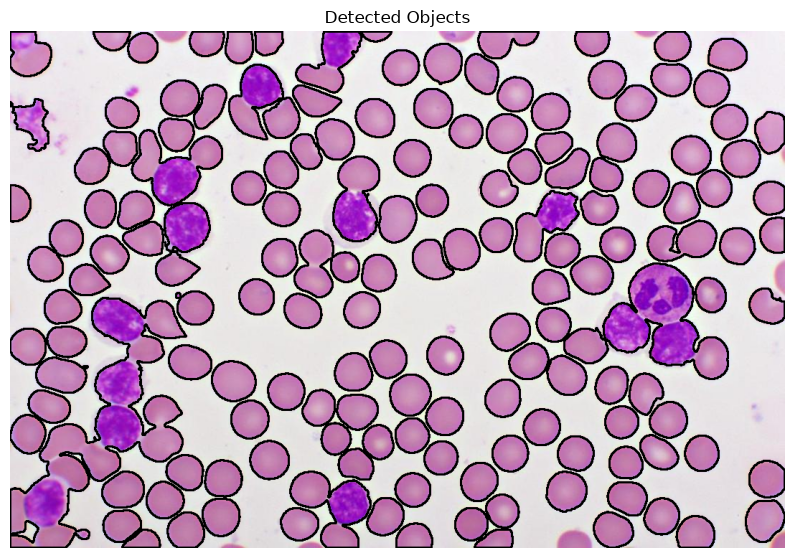

In [31]:

import cv2
import matplotlib.pyplot as plt

# قراءة الصورة
image = cv2.imread(r"C:\Users\PC-LAB1\Downloads\WhatsApp Image 2026-09-22 at 11.27.28 AM.jpeg")

# تحويل من BGR إلى RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# تحويل إلى رمادي
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# تحويل الصورة إلى أبيض وأسود
_, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)

# اكتشاف الأجسام
contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

count = 0

for contour in contours:

    # تجاهل الأجسام الصغيرة
    if cv2.contourArea(contour) < 1000:
        continue

    count += 1

    # رسم حدود الجسم
    cv2.drawContours(
        image_rgb,
        [contour],
        -1,
        (0, 0, 0),
        2
    )

print("Number of objects:", count)

# عرض الصورة باستخدام plt
plt.figure(figsize=(10, 7))
plt.imshow(image_rgb)
plt.title("Detected Objects")
plt.axis("off")
plt.show()


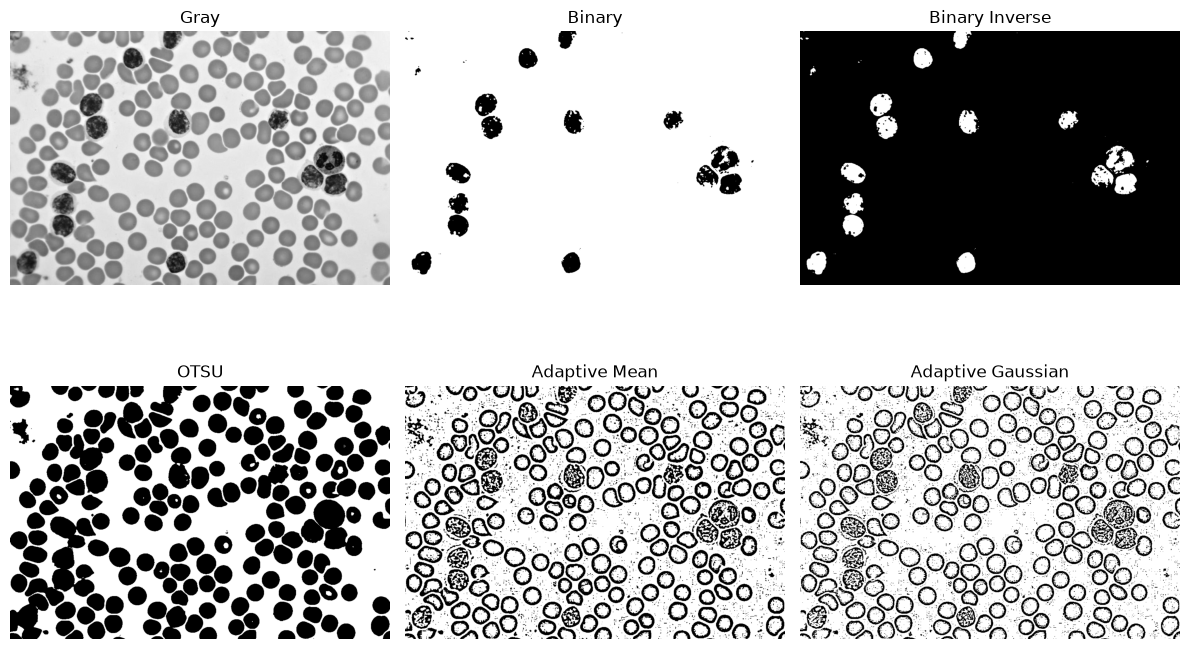

In [33]:
import cv2
import matplotlib.pyplot as plt

# قراءة الصورة
image = cv2.imread(
    r"C:\Users\PC-LAB1\Downloads\WhatsApp Image 2026-09-22 at 11.27.28 AM.jpeg"
)

# تحويل إلى Gray
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 1 - Threshold عادي
_, binary1 = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# 2 - Threshold عكسي
_, binary2 = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

# 3 - OTSU
_, binary3 = cv2.threshold(
    gray, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# 4 - Adaptive Mean
binary4 = cv2.adaptiveThreshold(
    gray, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    11, 2
)

# 5 - Adaptive Gaussian
binary5 = cv2.adaptiveThreshold(
    gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11, 2
)

# =========================
# عرض النتائج باستخدام plt
# =========================

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(gray, cmap="gray")
plt.title("Gray")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(binary1, cmap="gray")
plt.title("Binary")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(binary2, cmap="gray")
plt.title("Binary Inverse")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(binary3, cmap="gray")
plt.title("OTSU")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(binary4, cmap="gray")
plt.title("Adaptive Mean")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(binary5, cmap="gray")
plt.title("Adaptive Gaussian")
plt.axis("off")

plt.tight_layout()
plt.show()

Binary = 1 objects
Binary Inverse = 15 objects
Otsu = 3 objects
Adaptive Mean = 24 objects
Adaptive Gaussian = 23 objects


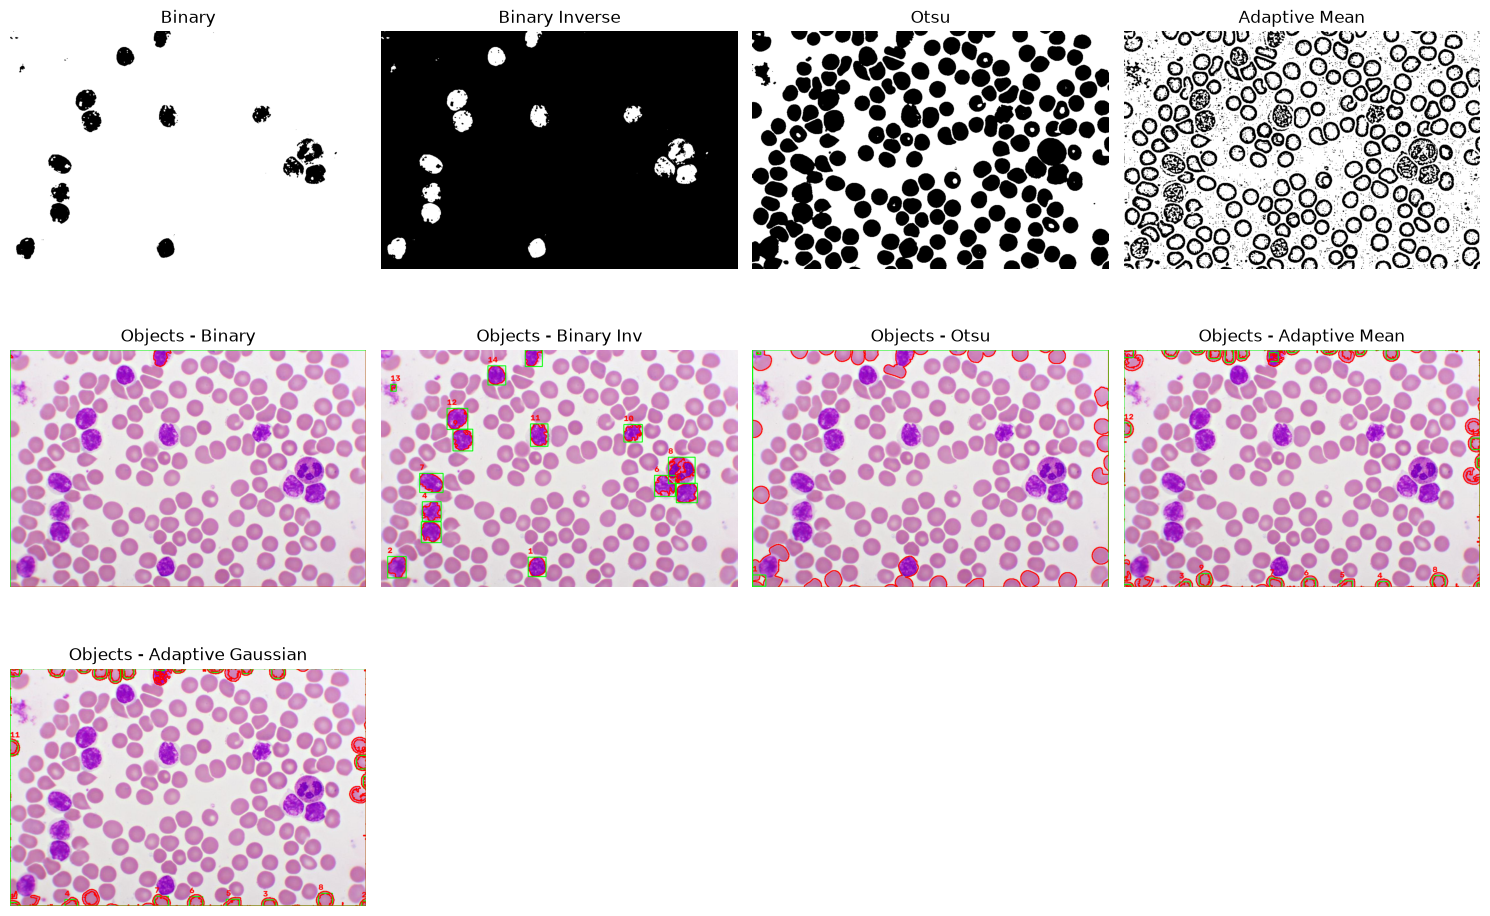

In [35]:

import cv2
import matplotlib.pyplot as plt

# قراءة الصورة
image = cv2.imread(
    r"C:\Users\PC-LAB1\Downloads\WhatsApp Image 2026-09-22 at 11.27.28 AM.jpeg"
)

# تحويل من BGR إلى RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# تحويل إلى رمادي
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


# =========================================================
# الطريقة 1: Binary Threshold
# =========================================================
_, binary = cv2.threshold(
    gray, 127, 255, cv2.THRESH_BINARY
)


# =========================================================
# الطريقة 2: Binary Inverse
# =========================================================
_, binary_inv = cv2.threshold(
    gray, 127, 255, cv2.THRESH_BINARY_INV
)


# =========================================================
# الطريقة 3: OTSU
# =========================================================
_, otsu = cv2.threshold(
    gray, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)


# =========================================================
# الطريقة 4: Adaptive Mean
# =========================================================
adaptive_mean = cv2.adaptiveThreshold(
    gray,
    255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)


# =========================================================
# الطريقة 5: Adaptive Gaussian
# =========================================================
adaptive_gaussian = cv2.adaptiveThreshold(
    gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)


# =========================================================
# دالة اكتشاف الأجسام
# =========================================================
def detect_objects(binary_image, title):

    # اكتشاف الأجسام
    contours, _ = cv2.findContours(
        binary_image,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # نسخة من الصورة الأصلية للرسم
    result = image_rgb.copy()

    count = 0

    for contour in contours:

        # تجاهل الأجسام الصغيرة
        if cv2.contourArea(contour) < 50:
            continue

        count += 1

        # رسم حدود الجسم
        cv2.drawContours(
            result,
            [contour],
            -1,
            (255, 0, 0),
            2
        )

        # Bounding Box
        x, y, w, h = cv2.boundingRect(contour)

        cv2.rectangle(
            result,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )

        # كتابة رقم الجسم
        cv2.putText(
            result,
            str(count),
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255, 0, 0),
            2
        )

    print(title, "=", count, "objects")

    return result


# =========================================================
# اكتشاف الأجسام بكل طريقة
# =========================================================

result_binary = detect_objects(
    binary,
    "Binary"
)

result_binary_inv = detect_objects(
    binary_inv,
    "Binary Inverse"
)

result_otsu = detect_objects(
    otsu,
    "Otsu"
)

result_adaptive_mean = detect_objects(
    adaptive_mean,
    "Adaptive Mean"
)

result_adaptive_gaussian = detect_objects(
    adaptive_gaussian,
    "Adaptive Gaussian"
)


# =========================================================
# عرض جميع النتائج
# =========================================================

plt.figure(figsize=(15, 10))

# Binary
plt.subplot(3, 4, 1)
plt.imshow(binary, cmap="gray")
plt.title("Binary")
plt.axis("off")

# Binary Inverse
plt.subplot(3, 4, 2)
plt.imshow(binary_inv, cmap="gray")
plt.title("Binary Inverse")
plt.axis("off")

# OTSU
plt.subplot(3, 4, 3)
plt.imshow(otsu, cmap="gray")
plt.title("Otsu")
plt.axis("off")

# Adaptive Mean
plt.subplot(3, 4, 4)
plt.imshow(adaptive_mean, cmap="gray")
plt.title("Adaptive Mean")
plt.axis("off")


# نتيجة Binary
plt.subplot(3, 4, 5)
plt.imshow(result_binary)
plt.title("Objects - Binary")
plt.axis("off")

# نتيجة Binary Inverse
plt.subplot(3, 4, 6)
plt.imshow(result_binary_inv)
plt.title("Objects - Binary Inv")
plt.axis("off")

# نتيجة OTSU
plt.subplot(3, 4, 7)
plt.imshow(result_otsu)
plt.title("Objects - Otsu")
plt.axis("off")

# نتيجة Adaptive Mean
plt.subplot(3, 4, 8)
plt.imshow(result_adaptive_mean)
plt.title("Objects - Adaptive Mean")
plt.axis("off")

# نتيجة Adaptive Gaussian
plt.subplot(3, 4, 9)
plt.imshow(result_adaptive_gaussian)
plt.title("Objects - Adaptive Gaussian")
plt.axis("off")

plt.tight_layout()
plt.show()



=== Exp 1 (Under-filtered) ===
المعاملات: Blur=(3, 3), MinArea=100, Morph=0
عدد الأجسام المكتشفة: 167

=== Exp 2 (Optimal) ===
المعاملات: Blur=(5, 5), MinArea=500, Morph=3
عدد الأجسام المكتشفة: 157

--> تم تصدير ملف التقرير CSV بنجاح باسم: objects_report.csv

=== Exp 3 (Over-filtered) ===
المعاملات: Blur=(11, 11), MinArea=2000, Morph=7
عدد الأجسام المكتشفة: 48



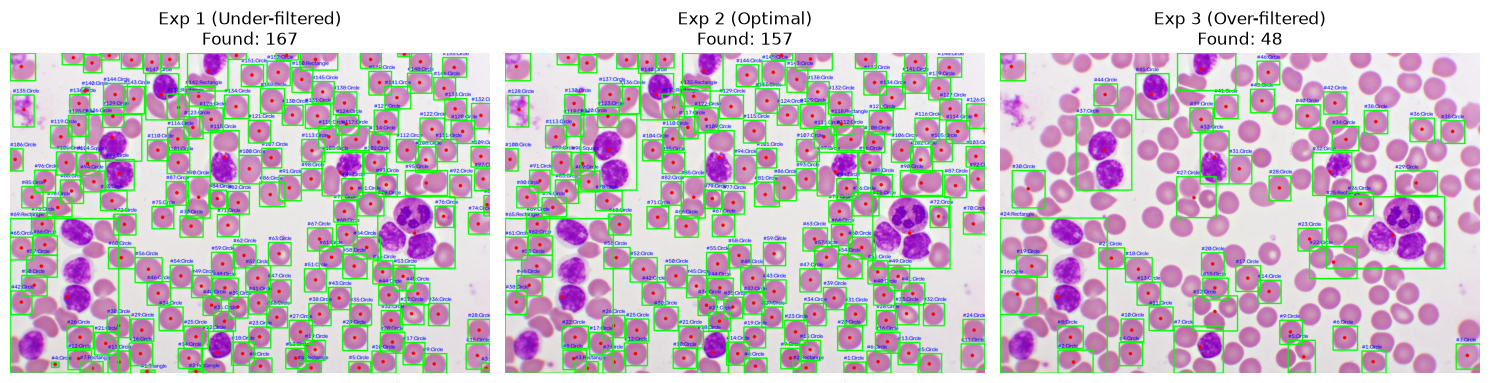

In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import csv  # مكتبة أساسية في بايثون لا تحتاج تثبيت

# 1. دالة تصنيف اللون باستعمال HSV
def get_dominant_color(image_bgr, contour):
    mask = np.zeros(image_bgr.shape[:2], dtype=np.uint8)
    cv2.drawContours(mask, [contour], -1, 255, -1)
    
    hsv_image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    mean_val = cv2.mean(hsv_image, mask=mask)
    h, s, v = mean_val[0], mean_val[1], mean_val[2]
    
    if s < 30 or v < 30:
        return "Other"
    elif (0 <= h <= 10) or (160 <= h <= 180):
        return "Red"
    elif 11 <= h <= 25:
        return "Orange"
    elif 26 <= h <= 35:
        return "Yellow"
    elif 36 <= h <= 85:
        return "Green"
    elif 86 <= h <= 130:
        return "Blue"
    else:
        return "Other"

# 2. دالة المعالجة وتطبيق الإعدادات
def process_pipeline(image_path, blur_kernel=(5, 5), min_area=500, morph_kernel_size=3):
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"لم يتم العثور على الصورة في: {image_path}")
        
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, blur_kernel, 0)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    if morph_kernel_size > 0:
        kernel = np.ones((morph_kernel_size, morph_kernel_size), np.uint8)
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
        
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    annotated = image.copy()
    data_list = []
    valid_count = 0
    
    for c in contours:
        area = cv2.contourArea(c)
        if area < min_area:
            continue
            
        valid_count += 1
        perimeter = cv2.arcLength(c, True)
        x, y, w, h = cv2.boundingRect(c)
        aspect_ratio = float(w) / h if h != 0 else 0
        
        M = cv2.moments(c)
        cX = int(M["m10"] / M["m00"]) if M["m00"] != 0 else 0
        cY = int(M["m01"] / M["m00"]) if M["m00"] != 0 else 0
        
        approx = cv2.approxPolyDP(c, 0.04 * perimeter, True)
        v = len(approx)
        if v == 3:
            shape = "Triangle"
        elif v == 4:
            shape = "Square" if 0.95 <= aspect_ratio <= 1.05 else "Rectangle"
        else:
            shape = "Circle"
            
        color = get_dominant_color(image, c)
        
        data_list.append({
            'id': valid_count,
            'color': color,
            'shape': shape,
            'area': round(area, 2),
            'perimeter': round(perimeter, 2),
            'x': x,
            'y': y,
            'width': w,
            'height': h,
            'cx': cX,
            'cy': cY,
            'aspect_ratio': round(aspect_ratio, 2)
        })
        
        cv2.rectangle(annotated, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.circle(annotated, (cX, cY), 4, (0, 0, 255), -1)
        cv2.putText(annotated, f"#{valid_count}:{shape}", (x, y - 5), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)
                    
    return annotated, data_list, valid_count

# دالة تصدير ملف CSV مباشرة
def save_to_csv(data_list, filename="objects_report.csv"):
    if not data_list:
        return
    keys = data_list[0].keys()
    with open(filename, 'w', newline='', encoding='utf-8') as output_file:
        dict_writer = csv.DictWriter(output_file, fieldnames=keys)
        dict_writer.writeheader()
        dict_writer.writerows(data_list)

# ==========================================
# تشغيل التجارب
# ==========================================
image_path = R"C:\Users\PC-LAB1\Downloads\WhatsApp Image 2026-09-22 at 11.27.28 AM.jpeg"

experiments = [
    {"name": "Exp 1 (Under-filtered)", "blur": (3, 3), "min_area": 100, "morph": 0},
    {"name": "Exp 2 (Optimal)", "blur": (5, 5), "min_area": 500, "morph": 3},
    {"name": "Exp 3 (Over-filtered)", "blur": (11, 11), "min_area": 2000, "morph": 7}
]

plt.figure(figsize=(15, 5))

for idx, exp in enumerate(experiments, start=1):
    annotated_img, data_result, total_found = process_pipeline(
        image_path, 
        blur_kernel=exp["blur"], 
        min_area=exp["min_area"], 
        morph_kernel_size=exp["morph"]
    )
    
    print(f"=== {exp['name']} ===")
    print(f"المعاملات: Blur={exp['blur']}, MinArea={exp['min_area']}, Morph={exp['morph']}")
    print(f"عدد الأجسام المكتشفة: {total_found}\n")
    
    if idx == 2:
        save_to_csv(data_result, "objects_report.csv")
        print("--> تم تصدير ملف التقرير CSV بنجاح باسم: objects_report.csv\n")
        
    plt.subplot(1, 3, idx)
    plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    plt.title(f"{exp['name']}\nFound: {total_found}")
    plt.axis('off')

plt.tight_layout()
plt.show()